In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

import seaborn as sns

In [2]:
!ls ../../input/titanic

gender_submission.csv  test.csv  train.csv


In [3]:
train_df = pd.read_csv("../../input/titanic/train.csv")
test_df = pd.read_csv("../../input/titanic/test.csv")

In [4]:
test_df["Survived"] = np.nan
data_df = pd.concat([train_df, test_df], ignore_index=True, sort=False)

In [5]:
display(data_df.head(3))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [6]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     891 non-null    float64
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


<Axes: xlabel='Sex', ylabel='Survived'>

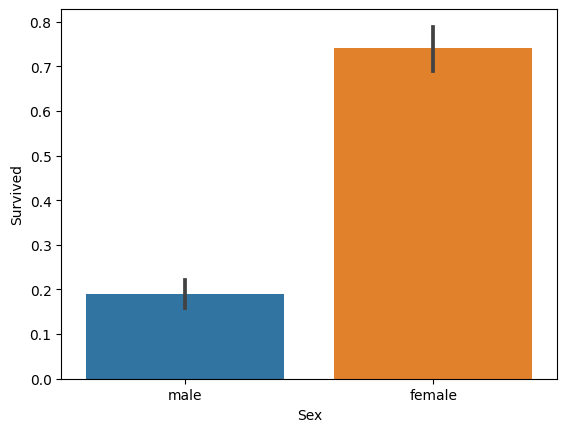

In [7]:
sns.barplot(x="Sex", y="Survived", data=data_df)

In [8]:
data_df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

In [9]:
isnull_age_index = data_df["Age"].isnull()
data_df[isnull_age_index].head(3)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0.0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1.0,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1.0,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C


In [10]:
def age_complement(in_df: pd.DataFrame, seed: int = 24) -> pd.DataFrame:
    out_df = in_df.copy()

    # ワンホットエンコーディング
    data_df = out_df[["Age", "Pclass", "Sex", "Parch", "SibSp"]]
    data_df = pd.get_dummies(data_df)

    notnull_data = data_df[data_df["Age"].notnull()].values
    isnull_data = data_df[data_df["Age"].isnull()].values

    # 年齢推定モデル構築
    rf_regressor = RandomForestRegressor(random_state=seed, n_estimators=100, n_jobs=-1)
    rf_regressor.fit(notnull_data[:, 1:], notnull_data[:, 0])

    # 年齢推定
    predict_age = rf_regressor.predict(isnull_data[:, 1:])
    out_df.loc[out_df["Age"].isnull(), "Age"] = np.round(predict_age)
    return out_df

In [11]:
data_df = age_complement(data_df)
data_df[isnull_age_index].head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0.0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,NaN,Q
17,18,1.0,2,"Williams, Mr. Charles Eugene",male,33.0,0,0,244373,13.0000,NaN,S
19,20,1.0,3,"Masselmani, Mrs. Fatima",female,24.0,0,0,2649,7.2250,NaN,C


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


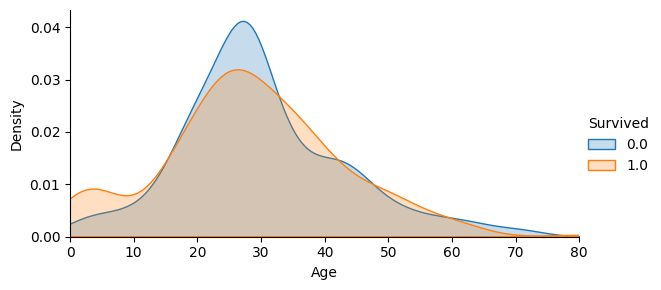

In [12]:
facet = sns.FacetGrid(data_df, hue="Survived", aspect=2)
facet.map(sns.kdeplot,"Age", fill=True)
facet.set(xlim=(0, data_df["Age"].max()))
facet.add_legend()

In [13]:
data_df.loc[data_df["Fare"].isna()]

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1043,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [14]:
def fare_complement(in_df: pd.DataFrame) -> pd.DataFrame:
    out_df = in_df.copy()
    fare_median = out_df.loc[(out_df["Embarked"] == "S") & (out_df["Pclass"] == 3), "Fare"].median()
    out_df["Fare"] = out_df["Fare"].fillna(fare_median)
    return out_df

In [15]:
def embarked_complement(in_df: pd.DataFrame) -> pd.DataFrame:
    out_df = in_df.copy()
    out_df["Embarked"] = out_df["Embarked"].fillna("S")
    return out_df

In [16]:
data_df = fare_complement(data_df)
data_df = embarked_complement(data_df)

In [17]:
data_df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age               0
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin          1014
Embarked          0
dtype: int64

In [18]:
train_df = data_df[data_df["Survived"].notnull()]
test_df = data_df[data_df["Survived"].isnull()].drop("Survived", axis=1)

In [19]:
display(train_df.head(3))
display(test_df.head(3))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
891,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
892,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
893,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
